<a href="https://colab.research.google.com/github/NatalhyBB/ProyectoFinal/blob/Proyecto/ProjectFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 0. INSTALACIÓN DE LIBRERÍAS Y AUTENTICACIÓN KAGGLE

!pip install -q kaggle scikit-learn tensorflow nltk matplotlib seaborn

from google.colab import files
import os

print("Sube tu archivo kaggle.json para autenticación (solo la primera vez)")
files.upload()  # Sube kaggle.json aquí

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

Sube tu archivo kaggle.json para autenticación (solo la primera vez)


Saving kaggle.json to kaggle.json


In [2]:
# 1. DESCARGA DEL DATASET DESDE KAGGLE

print("\n1. DESCARGANDO DATASET DE KAGGLE")

!kaggle datasets download -d 'jessevent/all-crypto-currencies' -p ./data --unzip

print("Archivos descargados:")
!ls ./data


1. DESCARGANDO DATASET DE KAGGLE
Dataset URL: https://www.kaggle.com/datasets/jessevent/all-crypto-currencies
License(s): other
  0% 0.00/22.5M [00:00<?, ?B/s]
100% 22.5M/22.5M [00:00<00:00, 541MB/s]
Archivos descargados:
crypto-markets.csv


In [4]:
import os
print("Archivos en './data':")
print(os.listdir('./data'))


Archivos en './data':
['crypto-markets.csv']


In [6]:
# 2. CARGA Y EXPLORACIÓN DE DATOS

print("\n2. CARGA Y EXPLORACIÓN DE DATOS")

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

file_path = './data/crypto-markets.csv'
df = pd.read_csv(file_path)

print(f"Dimensiones del dataset original: {df.shape}")

df_btc = df[df['symbol'] == 'BTC'].copy()

df_btc['date'] = pd.to_datetime(df_btc['date'])
df_btc.sort_values('date', inplace=True)
df_btc.set_index('date', inplace=True)

print(f"Dimensiones dataset Bitcoin: {df_btc.shape}")

from IPython.display import display, HTML
display(df_btc.head().style.set_table_attributes("style='display:inline; font-family: Arial; font-size: 14px;'").set_caption("Primeras 5 filas de Bitcoin"))



2. CARGA Y EXPLORACIÓN DE DATOS
Dimensiones del dataset original: (942297, 13)
Dimensiones dataset Bitcoin: (2042, 12)


,slug,symbol,name,ranknow,open,high,low,close,volume,market,close_ratio,spread
date,,,,,,,,,,,,
2013-04-28 00:00:00,bitcoin,BTC,Bitcoin,1,135.300000,135.980000,132.100000,134.210000,0.000000,1488566728.000000,0.543800,3.880000
2013-04-29 00:00:00,bitcoin,BTC,Bitcoin,1,134.440000,147.490000,134.000000,144.540000,0.000000,1603768865.000000,0.781300,13.490000
2013-04-30 00:00:00,bitcoin,BTC,Bitcoin,1,144.000000,146.930000,134.050000,139.000000,0.000000,1542813125.000000,0.384300,12.880000
2013-05-01 00:00:00,bitcoin,BTC,Bitcoin,1,139.000000,139.890000,107.720000,116.990000,0.000000,1298954594.000000,0.288200,32.170000
2013-05-02 00:00:00,bitcoin,BTC,Bitcoin,1,116.380000,125.600000,92.280000,105.210000,0.000000,1168517495.000000,0.388100,33.320000


In [8]:
print(df_btc.columns)

Index(['slug', 'symbol', 'name', 'ranknow', 'open', 'high', 'low', 'close',
       'volume', 'market', 'close_ratio', 'spread'],
      dtype='object')



3. ANÁLISIS EXPLORATORIO


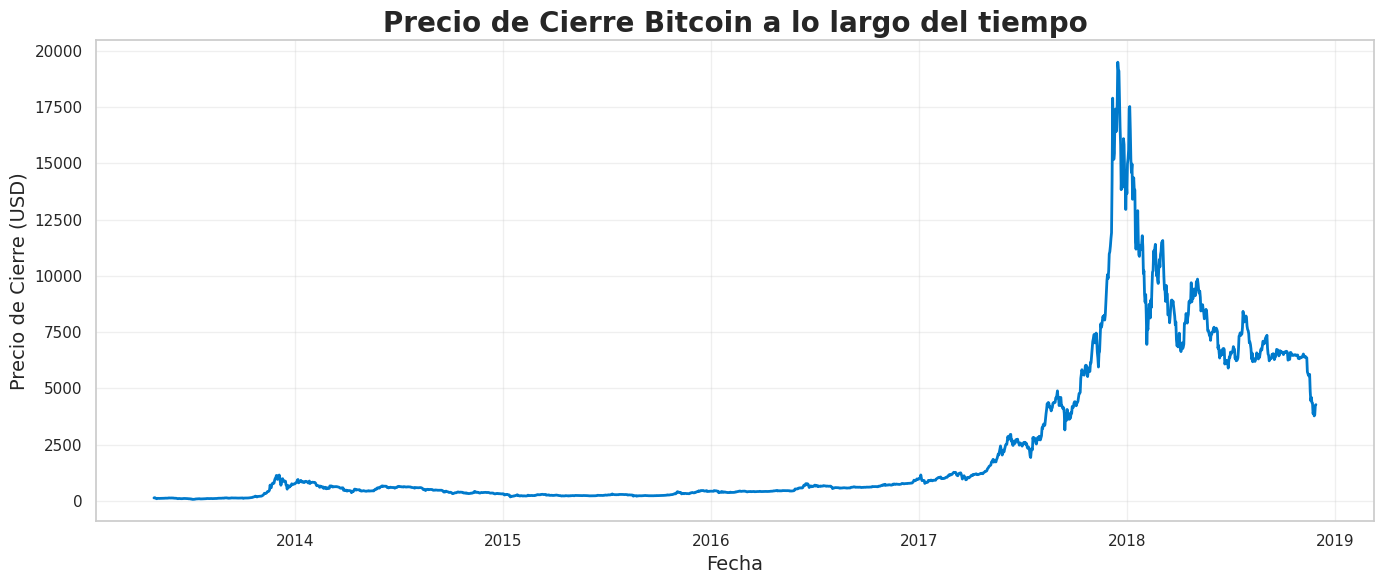

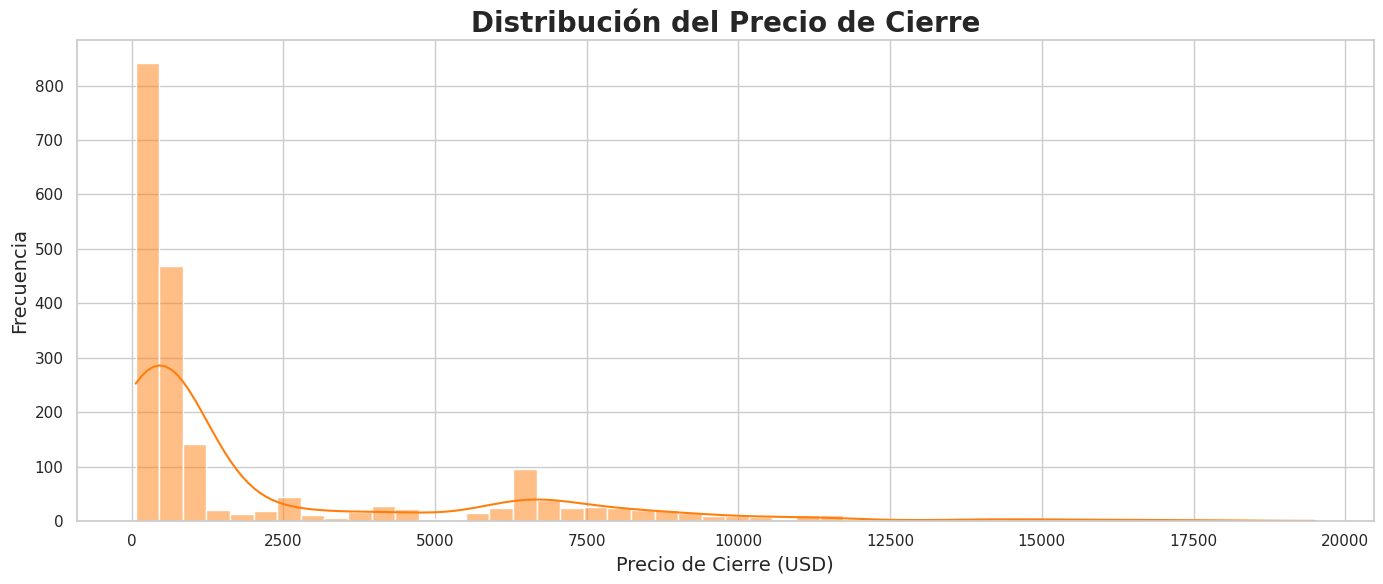

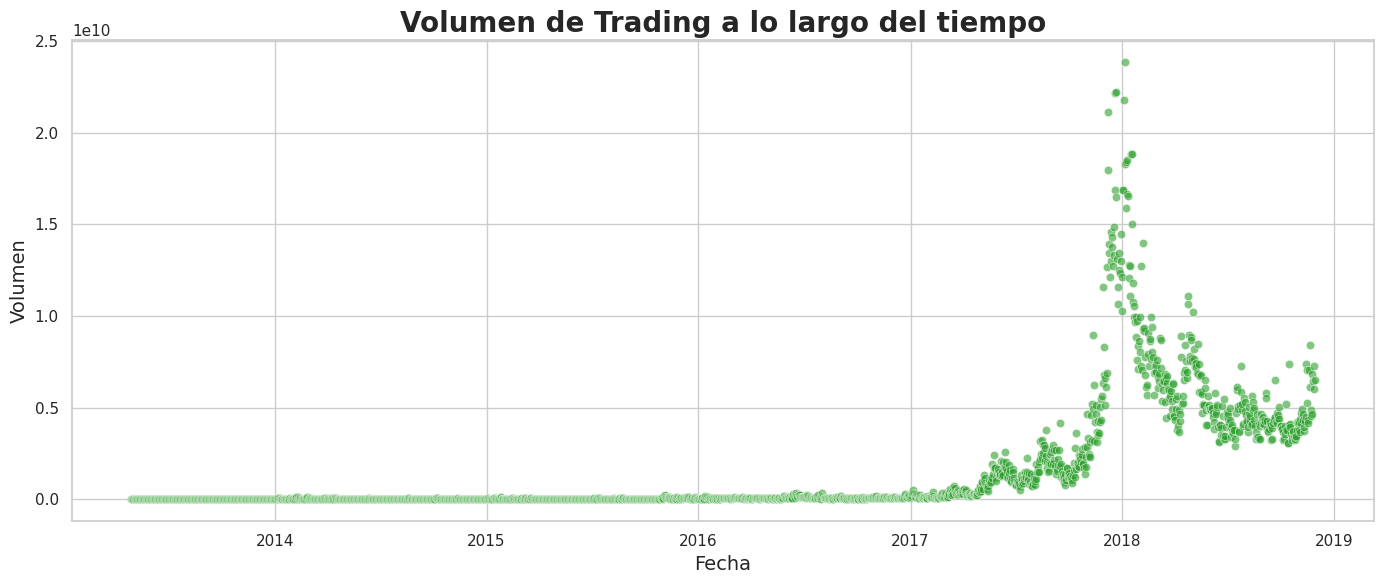

In [9]:
# 3. ANÁLISIS EXPLORATORIO DE DATOS

print("\n3. ANÁLISIS EXPLORATORIO")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14,6)

# Gráfico 1: Precio de cierre de Bitcoin a lo largo del tiempo
plt.figure()
sns.lineplot(data=df_btc, x=df_btc.index, y='close', color='#007acc', linewidth=2)
plt.title('Precio de Cierre Bitcoin a lo largo del tiempo', fontsize=20, fontweight='bold')
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Precio de Cierre (USD)', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 2: Histograma del precio de cierre
plt.figure()
sns.histplot(df_btc['close'], bins=50, kde=True, color='#ff7f0e')
plt.title('Distribución del Precio de Cierre', fontsize=20, fontweight='bold')
plt.xlabel('Precio de Cierre (USD)', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.tight_layout()
plt.show()

# Gráfico 3: Volumen de trading a lo largo del tiempo
plt.figure()
sns.scatterplot(data=df_btc, x=df_btc.index, y='volume', color='#2ca02c', alpha=0.6)
plt.title('Volumen de Trading a lo largo del tiempo', fontsize=20, fontweight='bold')
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Volumen', fontsize=14)
plt.tight_layout()
plt.show()



In [13]:
# 4. PREPARACIÓN DE DATOS PARA MODELO DE CLASIFICACIÓN

print("\n4. PREPARACIÓN DE DATOS PARA MODELO DE CLASIFICACIÓN")

df_btc['target'] = (df_btc['close'].shift(-1) > df_btc['close']).astype(int)
df_btc.dropna(inplace=True)

features = ['open', 'high', 'low', 'close', 'volume']
X = df_btc[features]
y = df_btc['target']

print(f"Características usadas para entrenamiento: {features}")
print(f"Tamaño dataset final (sin NA): {len(df_btc)}")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Tamaño conjunto entrenamiento: {len(X_train)}")
print(f"Tamaño conjunto prueba: {len(X_test)}")



4. PREPARACIÓN DE DATOS PARA MODELO DE CLASIFICACIÓN
Características usadas para entrenamiento: ['open', 'high', 'low', 'close', 'volume']
Tamaño dataset final (sin NA): 2042
Tamaño conjunto entrenamiento: 1633
Tamaño conjunto prueba: 409



5. ENTRENAMIENTO DE MODELO RANDOM FOREST

 Accuracy del modelo: 0.4841 



,precision,recall,f1-score,support
0,0.470,0.776,0.585,192.000
1,0.533,0.226,0.317,217.000
accuracy,0.484,0.484,0.484,0.484
macro avg,0.501,0.501,0.451,409.000
weighted avg,0.503,0.484,0.443,409.000


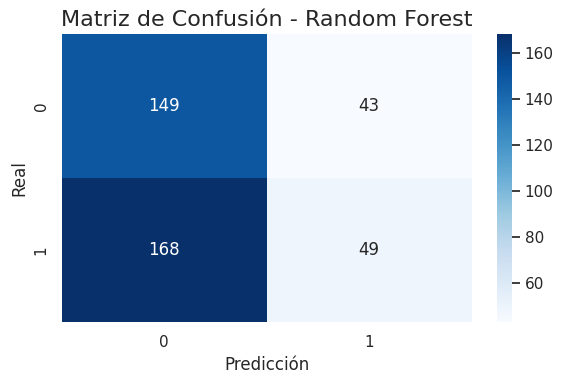

In [21]:
# 5. ENTRENAMIENTO DE MODELO RANDOM FOREST

print("\n5. ENTRENAMIENTO DE MODELO RANDOM FOREST")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from IPython.display import display

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n Accuracy del modelo: {acc:.4f} \n")

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

display(df_report.style.background_gradient(cmap='Blues').format(precision=3).set_caption("Reporte de Clasificación"))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
print("\n")
plt.title('Matriz de Confusión - Random Forest', fontsize=16)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()


In [26]:
# 6. ANÁLISIS DE SENTIMIENTO EN TEXTOS FINANCIEROS (ESPAÑOL)

print("\n6. ANÁLISIS DE SENTIMIENTO EN TEXTOS FINANCIEROS")

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from IPython.display import display

nltk.download('vader_lexicon')

textos = [
    "El precio de Bitcoin está subiendo rápidamente, señales alcistas fuertes.",
    "El mercado muestra signos de debilidad y una posible caída.",
    "Los inversores están optimistas sobre el crecimiento futuro.",
    "Se espera volatilidad e incertidumbre en el mercado.",
    "Tendencia bajista podría continuar a menos que aumente el volumen.",
    "Los analistas creen que la recuperación del mercado cripto ha comenzado."
]

sia = SentimentIntensityAnalyzer()
sentimientos = [sia.polarity_scores(texto) for texto in textos]

df_sentimientos = pd.DataFrame(sentimientos)
df_sentimientos['Texto'] = textos
df_sentimientos = df_sentimientos[['Texto', 'neg', 'neu', 'pos', 'compound']]

display(df_sentimientos.style
        .background_gradient(subset=['compound'], cmap='RdYlGn')
        .format(precision=3)
        .set_caption("Análisis de Sentimiento en Reportes Financieros (Español)"))



6. ANÁLISIS DE SENTIMIENTO EN TEXTOS FINANCIEROS


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,Texto,neg,neu,pos,compound
0,"El precio de Bitcoin está subiendo rápidamente, señales alcistas fuertes.",0.000,1.000,0.000,0.000
1,El mercado muestra signos de debilidad y una posible caída.,0.000,1.000,0.000,0.000
2,Los inversores están optimistas sobre el crecimiento futuro.,0.000,1.000,0.000,0.000
3,Se espera volatilidad e incertidumbre en el mercado.,0.000,1.000,0.000,0.000
4,Tendencia bajista podría continuar a menos que aumente el volumen.,0.000,1.000,0.000,0.000
5,Los analistas creen que la recuperación del mercado cripto ha comenzado.,0.000,0.806,0.194,0.340


In [28]:
# 7. PREPARACIÓN DE DATOS PARA RED NEURONAL LSTM

print("\n7. PREPARACIÓN DE DATOS PARA RED NEURONAL LSTM")

from sklearn.preprocessing import MinMaxScaler
import numpy as np

df_btc = df_btc.sort_index()

scaler = MinMaxScaler()
close_prices = df_btc['close'].values.reshape(-1, 1)
close_scaled = scaler.fit_transform(close_prices)

def create_sequences(data, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(data[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 60
X_lstm, y_lstm = create_sequences(close_scaled, seq_length)

split = int(0.8 * len(X_lstm))
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

print(f"Secuencia de entrenamiento: {X_train_lstm.shape}")
print(f"Secuencia de prueba: {X_test_lstm.shape}")




7. PREPARACIÓN DE DATOS PARA RED NEURONAL LSTM
Secuencia de entrenamiento: (1585, 60, 1)
Secuencia de prueba: (397, 60, 1)


In [30]:
# 8. CREACIÓN Y ENTRENAMIENTO DEL MODELO LSTM

print("\n8. CREACIÓN Y ENTRENAMIENTO DEL MODELO LSTM")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    callbacks=[early_stop],
    verbose=1
)


8. CREACIÓN Y ENTRENAMIENTO DEL MODELO LSTM
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0011 - val_loss: 0.0063
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 1.1020e-04 - val_loss: 0.0048
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 7.6234e-05 - val_loss: 0.0043
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 1.2580e-04 - val_loss: 0.0031
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 8.7759e-05 - val_loss: 0.0034
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 6.5248e-05 - val_loss: 0.0046
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 7.1559e-05 - val_loss: 0.0055
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 8.9622e-05 - val_loss: 0.0027
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 5.6394e-05 - val_loss: 0.0029
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 8.7890e-05 - val_loss: 0.0031
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 7.5547e-


9. EVALUACIÓN Y VISUALIZACIÓN DEL MODELO LSTM
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


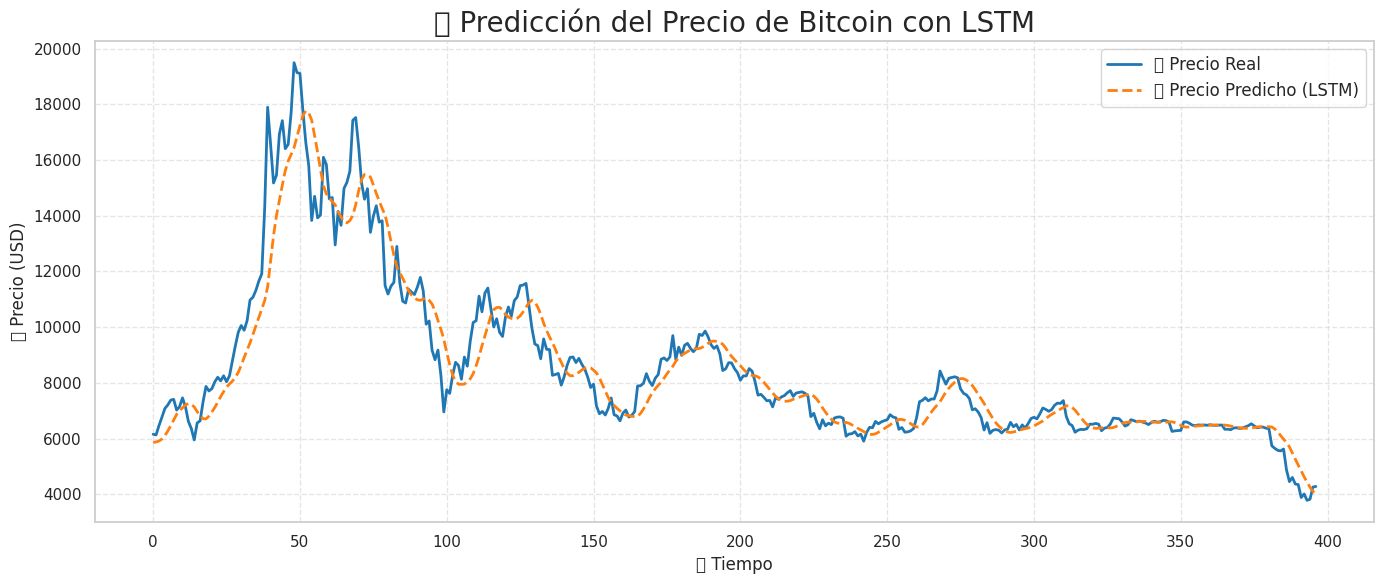

In [31]:
# 9. EVALUACIÓN Y VISUALIZACIÓN DEL MODELO LSTM

print("\n9. EVALUACIÓN Y VISUALIZACIÓN DEL MODELO LSTM")

predicted = model_lstm.predict(X_test_lstm)

predicted_prices = scaler.inverse_transform(predicted)
true_prices = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(true_prices, label='📉 Precio Real', color='#1f77b4', linewidth=2)
plt.plot(predicted_prices, label='📈 Precio Predicho (LSTM)', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('🔍 Predicción del Precio de Bitcoin con LSTM', fontsize=20)
plt.xlabel('⏱️ Tiempo', fontsize=12)
plt.ylabel('💰 Precio (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



10. GRÁFICOS COMPLEMENTARIOS DE TENDENCIA


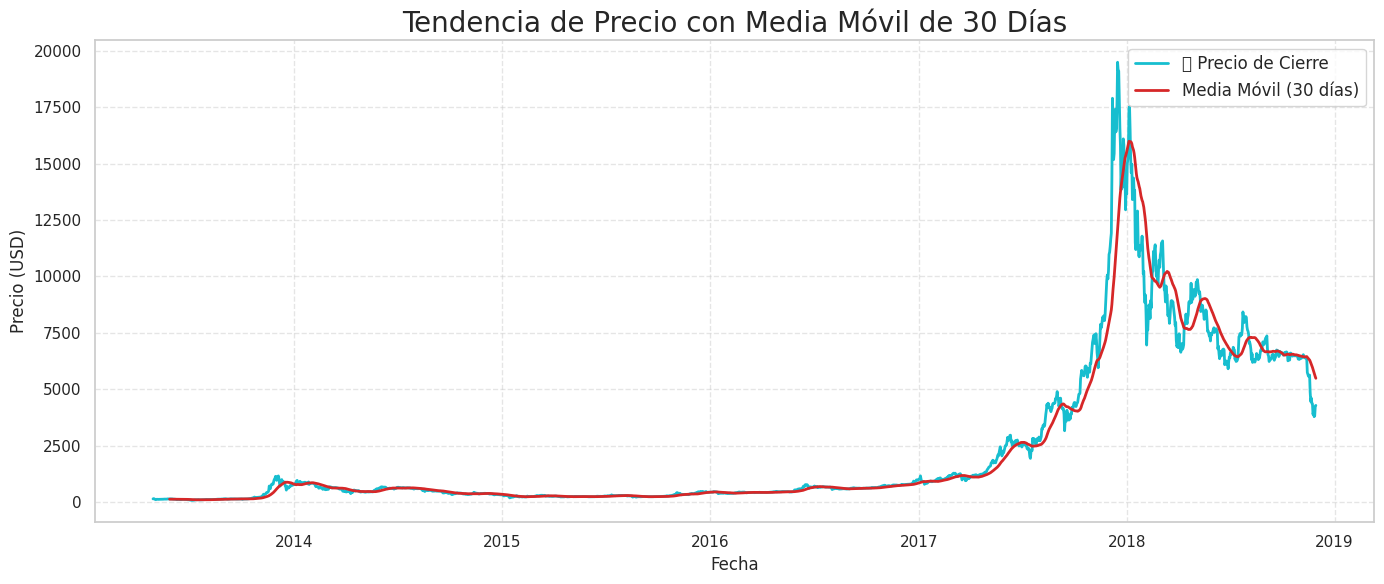

In [33]:
# 10. GRÁFICOS COMPLEMENTARIOS DE TENDENCIA

print("\n10. GRÁFICOS COMPLEMENTARIOS DE TENDENCIA")

df_btc['media_movil_30'] = df_btc['close'].rolling(window=30).mean()

plt.figure(figsize=(14,6))
plt.plot(df_btc.index, df_btc['close'], label='📉 Precio de Cierre', color='#17becf', linewidth=2)
plt.plot(df_btc.index, df_btc['media_movil_30'], label='Media Móvil (30 días)', color='#d62728', linewidth=2)

plt.title('Tendencia de Precio con Media Móvil de 30 Días', fontsize=20)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
